**Superstore Sales Analysis**

**Business Objective**
**Analyze historical sales data (2014–2017) to:**
- Identify revenue drivers
- Detect loss-making segments
- Evaluate discount impact on profitability
- Forecast future sales trends




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'],errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],errors='coerce')

# Create additional time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month-Year'] = df['Order Date'].dt.to_period('M')

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (9994, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month-Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10


------------------------------------------------------------------

Data Understanding Section

In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Overall Business KPIs**

In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")


Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793
Average Order Value: $458.61
Profit Margin: 12.47%


**KPI 1: Sales & Profit by Category**

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


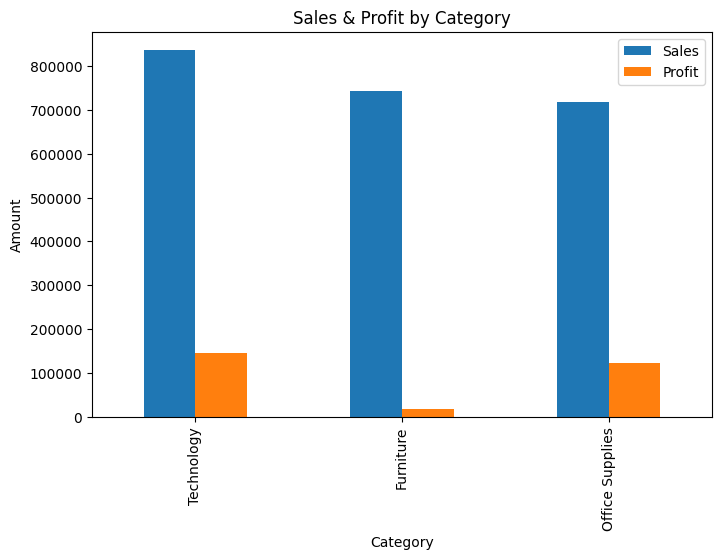

In [ ]:
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
print(category_analysis)

category_analysis.plot(kind='bar', figsize=(8,5))
plt.title("Sales & Profit by Category")
plt.ylabel("Amount")
plt.xlabel('Category')
plt.show()


Insights: Technology generates highest revenue

------------------------------------------------------------------

**KPI 2: Sales by Region**

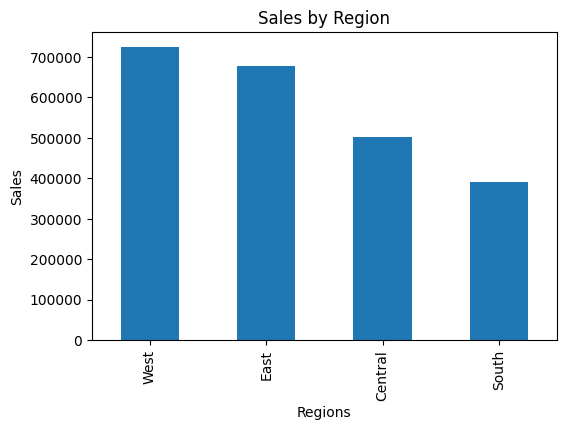

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', figsize=(6,4))
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.xlabel('Regions')
plt.show()

Insights: West region usually leads in sales

------------------------------------------------------------------

**KPI 3: Top 10 States by Sales**

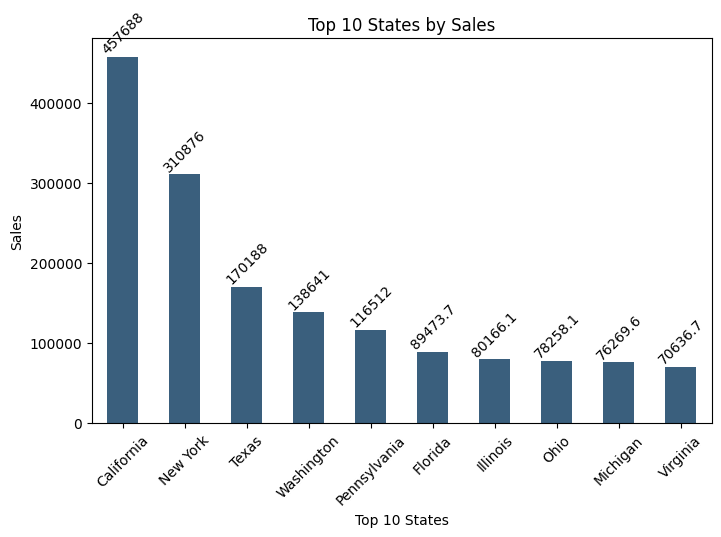

In [ ]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

ax = top_states.plot(kind='bar',y='Sales',x='State', figsize=(8,5), color='#3A5F7D')
ax.bar_label(ax.containers[0],rotation=45)
plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.xlabel('Top 10 States')
plt.xticks(rotation=45)
plt.show()


------------------------------------------------------------------

**KPI 4: Sub-Category Profitability**

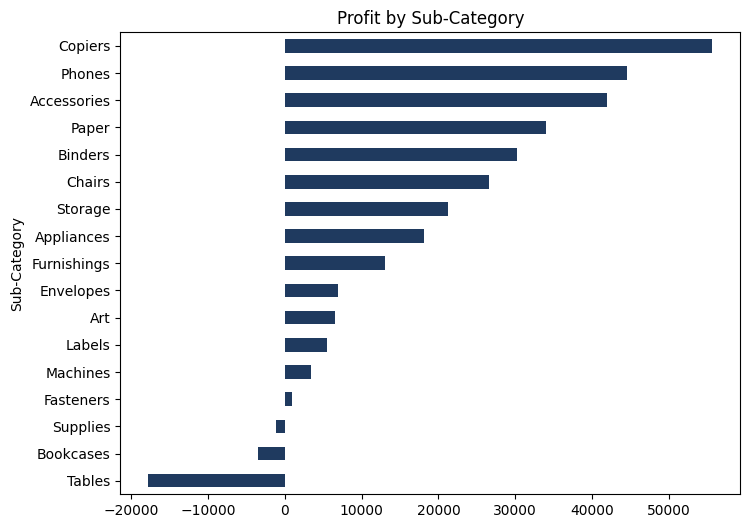

In [ ]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

subcat_profit.plot(kind='barh', figsize=(8,6),color='#1F3A5F')
plt.title("Profit by Sub-Category")
plt.show()


Insights: Tables sub-category often shows losses

------------------------------------------------------------------

**KPI 5: Discount Impact on Profit**

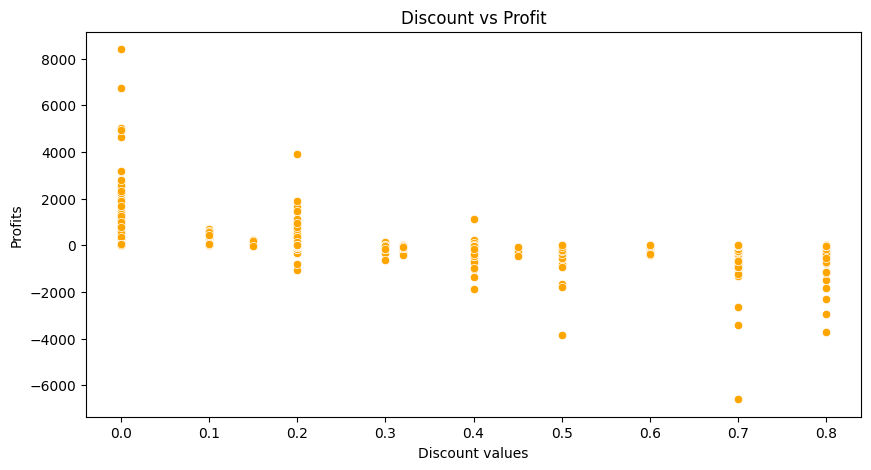

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Discount', y='Profit',color='orange')
plt.title("Discount vs Profit")
plt.xlabel('Discount values')
plt.ylabel('Profits')
plt.show()


Insights: High discounts (>30%) reduce profitability

------------------------------------------------------------------

**KPI 6: Time Series Analysis**

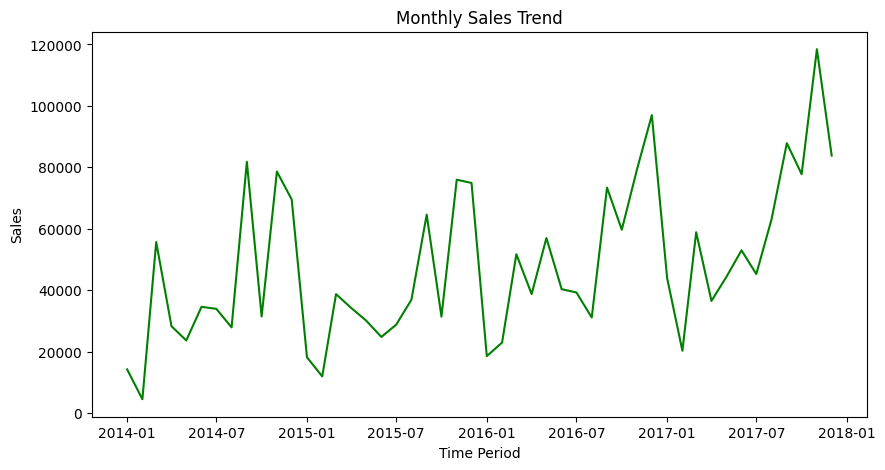

In [ ]:
monthly_sales = df.groupby('Month-Year')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales,color='green')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel('Time Period')
plt.show()


Insights: Sales peak during Q4 (holiday season)

------------------------------------------------------------------

**Business Recommendations**

1. Reduce high discount dependency (>30%) to improve margins.
2. Re-evaluate loss-making sub-categories like Tables.
3. Invest more in Technology category marketing.
4. Optimize shipping times in slow regions.
